In [1]:
# ============================================================
# CELL 1 — Install & Import Libraries
# ============================================================

!pip install lightgbm imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, warnings

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay,
    precision_recall_curve
)
import lightgbm as lgb
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ============================================================
# CONSTANTS
# ============================================================
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
MIN_COMBO     = 5      # min samples for target encoding combos
PSEUDO_CONF_R = 0.80   # confidence threshold for Resistant pseudo-labels
PSEUDO_CONF_S = 0.20   # confidence threshold for Susceptible pseudo-labels
MAX_SUS_RATIO = 2.5    # max Susceptible:Resistant pseudo-label ratio

print("✅ Libraries imported.")
print(f"   pandas     : {pd.__version__}")
print(f"   lightgbm   : {lgb.__version__}")


✅ Libraries imported.
   pandas     : 2.2.2
   lightgbm   : 4.6.0


  RAW DATASET AUDIT
  Shape        : 121,589 rows × 21 columns
  Memory       : 99.8 MB

--- Missing values ---
                                  null_count  null_pct    dtype
Laboratory Typing Method Version      121583  100.0000   object
Source                                121545   99.9600   object
Laboratory Typing Platform            120675   99.2500   object
Measurement Sign                      119469   98.2600   object
Testing Standard Year                 118936   97.8200  float64
Testing Standard                      117865   96.9400   object
PubMed                                116728   96.0000   object
Laboratory Typing Method              115855   95.2800   object
Vendor                                 95340   78.4100   object
Resistant Phenotype                    62562   51.4500   object
Measurement Value                      58521   48.1300   object
Measurement Unit                       58521   48.1300   object
Measurement                            58522   48.1300  

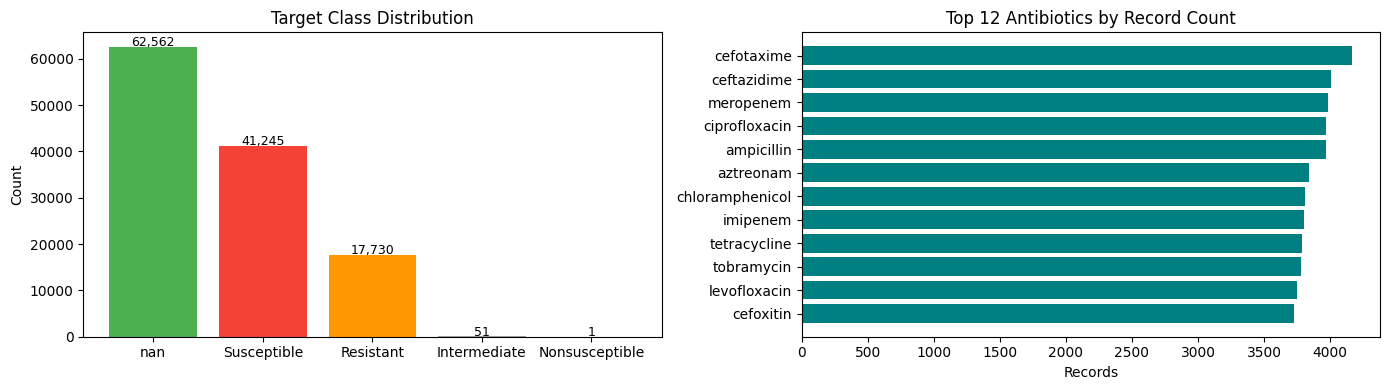

Saved: eda_overview_lgbm.png


In [6]:
# ============================================================
# CELL 2 — Load Dataset & Initial Audit
# ============================================================

FILE_PATH = "BVBRC_genome_amr.csv"

df_raw = pd.read_csv(FILE_PATH, low_memory=False)

print("=" * 55)
print("  RAW DATASET AUDIT")
print("=" * 55)
print(f"  Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Memory       : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n--- Missing values ---")
null_df = pd.DataFrame({
    'null_count': df_raw.isnull().sum(),
    'null_pct'  : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'dtype'     : df_raw.dtypes
}).sort_values('null_pct', ascending=False)
print(null_df.to_string())

print("\n--- Target distribution ---")
print(df_raw['Resistant Phenotype'].value_counts(dropna=False).to_string())

print(f"\n--- Unique antibiotics : {df_raw['Antibiotic'].nunique()} ---")
print(df_raw['Antibiotic'].value_counts().head(10).to_string())
print(f"\n  Unique Genome IDs   : {df_raw['Genome ID'].nunique():,}")
print(f"  Unique Taxon IDs    : {df_raw['Taxon ID'].nunique():,}")

# ── IMPROVEMENT: EDA plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc = df_raw['Resistant Phenotype'].value_counts(dropna=False)
axes[0].bar(vc.index.astype(str), vc.values, color=['#4CAF50','#F44336','#FF9800','#9E9E9E'])
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{bar.get_height():,}", ha='center', fontsize=9)

top_ab = df_raw['Antibiotic'].value_counts().head(12)
axes[1].barh(top_ab.index[::-1], top_ab.values[::-1], color='teal')
axes[1].set_title('Top 12 Antibiotics by Record Count')
axes[1].set_xlabel('Records')

plt.tight_layout()
plt.savefig('eda_overview_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_overview_lgbm.png")


In [7]:
# ============================================================
# CELL 3 — Full Cleaning Pipeline (LightGBM Edition)
# ============================================================
# HOW THIS DIFFERS FROM THE XGBOOST PIPELINE:
#
#   1. Categoricals kept as 'category' dtype — LightGBM handles
#      them natively, outperforming ordinal encoding on high-
#      cardinality columns like Antibiotic and genus.
#
#   2. mic_value nulls LEFT as NaN — LightGBM learns the best
#      branch for NaN rows automatically. Filling would add noise.
#
#   3. strain NOT extracted (same reasoning as XGBoost V4:
#      100k+ unique values → pure overfitting risk).
#
#   4. species IS extracted (sub-genus signal, safe cardinality).
#
#   5. IMPROVEMENT: EDA — MIC distribution plot added.
# ============================================================

import pandas as pd
import numpy as np
import re

df = df_raw.copy()
print(f"Starting shape: {df.shape[0]:,} rows\n")

MIC_SIGN_MAP = {'<=': -1.0, '<': -0.5, '=': 0.0, '==': 0.0,
                'exact': 0.0, '>=': 1.0, '>': 0.5, 'unknown': 0.0}

def parse_mic_sign(val):
    if pd.isna(val): return 'unknown'
    val = str(val).strip()
    for op in ['<=', '>=', '==', '<', '>', '=']:
        if val.startswith(op): return op
    return 'exact'

def parse_mic_numeric(val):
    if pd.isna(val): return np.nan
    m = re.search(r'(\d+\.?\d*)', str(val))
    return float(m.group(1)) if m else np.nan

df['mic_sign']  = df['Measurement'].apply(parse_mic_sign)
df['mic_value'] = df['Measurement'].apply(parse_mic_numeric)

mask_no_mic = df['mic_value'].isna()
df.loc[mask_no_mic, 'mic_value'] = (
    df.loc[mask_no_mic, 'Measurement Value']
      .astype(str).apply(parse_mic_numeric)
)

df['has_mic']  = df['mic_value'].notna().astype(int)
df['mic_log']  = np.log1p(df['mic_value'].clip(lower=0))   # NaN stays NaN — LightGBM handles
print(f"STEP 1 — MIC parsed | with MIC: {df['mic_value'].notna().sum():,}")

def extract_genome_parts(name):
    if pd.isna(name):
        return pd.Series({'genus': 'unknown', 'species': 'unknown'})
    parts = str(name).strip().split(None, 2)
    genus   = parts[0].strip("\'\"").capitalize() if len(parts) > 0 else 'unknown'
    species = parts[1].lower()                    if len(parts) > 1 else 'unknown'
    return pd.Series({'genus': genus, 'species': species})

genome_parts = df['Genome Name'].apply(extract_genome_parts)
df = pd.concat([df, genome_parts], axis=1)
print(f"STEP 2 — Genome Name parsed | genera: {df['genus'].nunique()} | species: {df['species'].nunique()}")

df_unlabeled = df[df['Resistant Phenotype'].isna()].copy()
df           = df[df['Resistant Phenotype'].notna()].copy()
print(f"\nSTEP 3 — Labeled: {len(df):,} | Unlabeled: {len(df_unlabeled):,}")

merge_map = {
    'Susceptible'   : 'Susceptible',
    'Resistant'     : 'Resistant',
    'Intermediate'  : 'Resistant',
    'Nonsusceptible': 'Resistant',
}
df['Resistant Phenotype'] = df['Resistant Phenotype'].map(merge_map)
df['target'] = (df['Resistant Phenotype'] == 'Resistant').astype(int)
df['Antibiotic']           = df['Antibiotic'].str.strip().str.lower()
df_unlabeled['Antibiotic'] = df_unlabeled['Antibiotic'].str.strip().str.lower()

vc = df['target'].value_counts()
print(f"STEP 4 — Susceptible (0): {vc[0]:,} | Resistant (1): {vc[1]:,}")

print("\nSTEP 5 — MIC Rule-Based Rescue...")
s_bounds = df[df['target'] == 0].groupby('Antibiotic')['mic_value'].quantile(0.90)
r_bounds = df[df['target'] == 1].groupby('Antibiotic')['mic_value'].quantile(0.10)

rescued_rows = []
for idx, row in df_unlabeled.iterrows():
    if pd.isna(row['mic_value']): continue
    ab = row['Antibiotic']; mic = row['mic_value']
    if ab not in s_bounds.index or ab not in r_bounds.index: continue
    s_max = s_bounds[ab]; r_min = r_bounds[ab]
    if mic <= s_max and mic < r_min:
        r = row.copy(); r['target'] = 0; rescued_rows.append(r)
    elif mic >= r_min and mic > s_max:
        r = row.copy(); r['target'] = 1; rescued_rows.append(r)

if rescued_rows:
    df_rescued = pd.DataFrame(rescued_rows)
    df_rescued['Resistant Phenotype'] = df_rescued['target'].map({0:'Susceptible',1:'Resistant'})
    df = pd.concat([df, df_rescued], axis=0).reset_index(drop=True)
    df_unlabeled = df_unlabeled[~df_unlabeled.index.isin(df_rescued.index)].copy()
    print(f"         Rescued: {len(df_rescued):,} rows")
else:
    print("         No rows rescued.")
print(f"         Training pool: {len(df):,} | Still unlabeled: {len(df_unlabeled):,}")

df['is_lab_confirmed'] = (df['Evidence'] == 'Laboratory Method').astype(int)
before = len(df)
df = (df.sort_values(['Genome ID','Antibiotic','is_lab_confirmed'],
                     ascending=[True, True, False])
        .drop_duplicates(subset=['Genome ID','Antibiotic'], keep='first')
        .reset_index(drop=True))
print(f"\nSTEP 6 — Duplicates removed: {before - len(df):,}")

DRUG_CLASS_MAP = {
    'ampicillin':'beta_lactam','amoxicillin':'beta_lactam',
    'piperacillin':'beta_lactam','piperacillin/tazobactam':'beta_lactam',
    'oxacillin':'beta_lactam','cefazolin':'beta_lactam',
    'cefoxitin':'beta_lactam','cefotaxime':'beta_lactam',
    'ceftazidime':'beta_lactam','ceftriaxone':'beta_lactam',
    'cefepime':'beta_lactam','cefuroxime':'beta_lactam','cephalothin':'beta_lactam',
    'imipenem':'carbapenem','meropenem':'carbapenem',
    'ertapenem':'carbapenem','doripenem':'carbapenem',
    'aztreonam':'monobactam',
    'ciprofloxacin':'fluoroquinolone','levofloxacin':'fluoroquinolone',
    'norfloxacin':'fluoroquinolone','nalidixic acid':'fluoroquinolone','ofloxacin':'fluoroquinolone',
    'gentamicin':'aminoglycoside','tobramycin':'aminoglycoside',
    'amikacin':'aminoglycoside','streptomycin':'aminoglycoside',
    'neomycin':'aminoglycoside','kanamycin':'aminoglycoside',
    'tetracycline':'tetracycline','doxycycline':'tetracycline',
    'minocycline':'tetracycline','tigecycline':'tetracycline',
    'sulfamethoxazole':'sulfonamide','trimethoprim':'sulfonamide',
    'trimethoprim/sulfamethoxazole':'sulfonamide',
    'chloramphenicol':'phenicol',
    'azithromycin':'macrolide','erythromycin':'macrolide',
    'colistin':'polymyxin','polymyxin b':'polymyxin',
    'vancomycin':'glycopeptide','teicoplanin':'glycopeptide',
    'clindamycin':'lincosamide','nitrofurantoin':'nitrofuran',
    'rifampicin':'rifamycin','rifampin':'rifamycin',
}
df['drug_class']           = df['Antibiotic'].map(DRUG_CLASS_MAP).fillna('other')
df_unlabeled['drug_class'] = df_unlabeled['Antibiotic'].map(DRUG_CLASS_MAP).fillna('other')
print(f"\nSTEP 7 — Drug classes: {df['drug_class'].value_counts().to_dict()}")

def extract_f1_score(text):
    if pd.isna(text): return np.nan
    m = re.search(r'F1 score:\s*([\d.]+)', str(text))
    return float(m.group(1)) if m else np.nan

df['computational_f1'] = df['Computational Method Performance'].apply(extract_f1_score)
df.loc[df['is_lab_confirmed'] == 1, 'computational_f1'] = 1.0
median_f1 = df['computational_f1'].median()
df['computational_f1'] = df['computational_f1'].fillna(median_f1)
df['sample_weight']    = df['computational_f1'].clip(0.5, 1.0)
print(f"\nSTEP 8 — Sample weights: {df['sample_weight'].min():.2f} – {df['sample_weight'].max():.2f}")

DROP_FINAL = [
    'Genome Name','Resistant Phenotype',
    'Measurement','Measurement Sign','Measurement Value','Measurement Unit',
    'Laboratory Typing Method','Laboratory Typing Method Version',
    'Laboratory Typing Platform','Vendor','Testing Standard','Testing Standard Year',
    'Computational Method','Computational Method Version',
    'Computational Method Performance','Evidence','Source','PubMed',
]
DROP_FINAL = [c for c in DROP_FINAL if c in df.columns]
df.drop(columns=DROP_FINAL, inplace=True)
print(f"\nSTEP 9 — Dropped {len(DROP_FINAL)} raw columns")

CAT_COLS = ['Antibiotic', 'drug_class', 'genus', 'species', 'mic_sign']
for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].astype('category')
print(f"\nSTEP 10 — Category columns: {CAT_COLS}")

print(f"\n{'='*55}")
print(f"  CLEANING COMPLETE")
print(f"  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
vc = df['target'].value_counts()
print(f"  Target: 0={vc[0]:,} | 1={vc[1]:,}")
print(f"  Columns: {list(df.columns)}")

df_clean = df.copy()
print("\n✅ df_clean ready.")


Starting shape: 121,589 rows

STEP 1 — MIC parsed | with MIC: 63,068
STEP 2 — Genome Name parsed | genera: 1 | species: 1

STEP 3 — Labeled: 59,027 | Unlabeled: 62,562
STEP 4 — Susceptible (0): 41,245 | Resistant (1): 17,782

STEP 5 — MIC Rule-Based Rescue...
         Rescued: 32,756 rows
         Training pool: 91,783 | Still unlabeled: 29,806

STEP 6 — Duplicates removed: 957

STEP 7 — Drug classes: {'beta_lactam': 30728, 'other': 12009, 'carbapenem': 10220, 'aminoglycoside': 9943, 'fluoroquinolone': 9868, 'sulfonamide': 6070, 'tetracycline': 4931, 'phenicol': 3642, 'monobactam': 1957, 'nitrofuran': 1428, 'macrolide': 17, 'polymyxin': 11, 'rifamycin': 1, 'glycopeptide': 1}

STEP 8 — Sample weights: 0.76 – 1.00

STEP 9 — Dropped 18 raw columns

STEP 10 — Category columns: ['Antibiotic', 'drug_class', 'genus', 'species', 'mic_sign']

  CLEANING COMPLETE
  Shape : 90,826 rows × 14 columns
  Target: 0=62,844 | 1=27,982
  Columns: ['Taxon ID', 'Genome ID', 'Antibiotic', 'mic_sign', 'mic_v

In [8]:
# ============================================================
# CELL 4 — Feature Engineering & Train/Test Split (FIXED)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold

df = df_clean.copy()
global_mean = None

CAT_COLS = ['Antibiotic', 'drug_class', 'genus', 'species', 'mic_sign']
for col in CAT_COLS:
    if col in df_unlabeled.columns:
        df_unlabeled[col] = df_unlabeled[col].astype('category')
    else:
        df_unlabeled[col] = pd.Categorical(['unknown'] * len(df_unlabeled))

df_unlabeled['Antibiotic'] = df_unlabeled['Antibiotic'].str.strip().str.lower().astype('category')
df_unlabeled['mic_value']  = df_unlabeled.get('mic_value', pd.Series(np.nan, index=df_unlabeled.index))
df_unlabeled['has_mic']    = df_unlabeled['mic_value'].notna().astype(int)
df_unlabeled['mic_log']    = np.log1p(pd.to_numeric(df_unlabeled['mic_value'], errors='coerce').clip(lower=0))
df_unlabeled['mic_sign']   = (df_unlabeled.get('mic_sign', pd.Series('unknown', index=df_unlabeled.index))
                               .astype('category') if 'mic_sign' in df_unlabeled.columns
                               else pd.Categorical(['unknown'] * len(df_unlabeled)))

for col, default in [('is_lab_confirmed', 0), ('computational_f1', df['computational_f1'].median())]:
    if col not in df_unlabeled.columns:
        df_unlabeled[col] = default

BASE_FEATURES = [
    'Taxon ID', 'Antibiotic', 'drug_class', 'genus', 'species', 'mic_sign',
    'is_lab_confirmed', 'computational_f1', 'mic_value', 'mic_log', 'has_mic',
]
TARGET = 'target'

X = df[BASE_FEATURES]; y = df[TARGET]; w = df['sample_weight']
X_train_raw, X_test_raw, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Split — Train: {len(X_train_raw):,} | Test: {len(X_test_raw):,}")

global_mean = y_train.mean()
print(f"Global mean (resistance rate): {global_mean:.4f}")

print("\nBuilding target encodings with 5-fold CV...")

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_df = X_train_raw.copy()
train_df['target'] = y_train.values

for col in ['ab_resistance_rate', 'taxon_ab_resistance_rate', 'genus_ab_resistance_rate']:
    train_df[col] = global_mean

for fold_idx, (trn_idx, val_idx) in enumerate(kf.split(train_df)):
    trn_fold = train_df.iloc[trn_idx]
    val_rows = train_df.iloc[val_idx]

    ab_rate = trn_fold.groupby('Antibiotic', observed=True)['target'].mean()
    train_df.loc[train_df.index[val_idx], 'ab_resistance_rate'] = (
        val_rows['Antibiotic'].map(ab_rate).fillna(global_mean).values
    )

    taxon_counts = trn_fold.groupby(['Taxon ID','Antibiotic'], observed=True)['target'].count()
    taxon_rate   = trn_fold.groupby(['Taxon ID','Antibiotic'], observed=True)['target'].mean()
    taxon_rate   = taxon_rate[taxon_counts >= MIN_COMBO].reset_index()
    taxon_rate.columns = ['Taxon ID','Antibiotic','taxon_ab_resistance_rate']

    if taxon_rate.empty:
        train_df.loc[train_df.index[val_idx], 'taxon_ab_resistance_rate'] = (
            val_rows['Antibiotic'].map(ab_rate).fillna(global_mean).values
        )
    else:
        val_m = val_rows.reset_index().drop(columns=['taxon_ab_resistance_rate']).merge(
            taxon_rate, on=['Taxon ID','Antibiotic'], how='left'
        )
        val_m['taxon_ab_resistance_rate'] = val_m['taxon_ab_resistance_rate'].fillna(
            val_m['Antibiotic'].map(ab_rate).fillna(global_mean)
        )
        train_df.loc[train_df.index[val_idx], 'taxon_ab_resistance_rate'] = val_m['taxon_ab_resistance_rate'].values

    genus_counts = trn_fold.groupby(['genus','Antibiotic'], observed=True)['target'].count()
    genus_rate   = trn_fold.groupby(['genus','Antibiotic'], observed=True)['target'].mean()
    genus_rate   = genus_rate[genus_counts >= MIN_COMBO].reset_index()
    genus_rate.columns = ['genus','Antibiotic','genus_ab_resistance_rate']

    if genus_rate.empty:
        train_df.loc[train_df.index[val_idx], 'genus_ab_resistance_rate'] = (
            val_rows['Antibiotic'].map(ab_rate).fillna(global_mean).values
        )
    else:
        val_m2 = val_rows.reset_index().drop(columns=['genus_ab_resistance_rate']).merge(
            genus_rate, on=['genus','Antibiotic'], how='left'
        )
        val_m2['genus_ab_resistance_rate'] = val_m2['genus_ab_resistance_rate'].fillna(
            val_m2['Antibiotic'].map(ab_rate).fillna(global_mean)
        )
        train_df.loc[train_df.index[val_idx], 'genus_ab_resistance_rate'] = val_m2['genus_ab_resistance_rate'].values

print("  ✅ 5-fold target encoding complete")

ab_rate_full       = train_df.groupby('Antibiotic', observed=True)['target'].mean()
taxon_ab_rate_full = (train_df.groupby(['Taxon ID','Antibiotic'], observed=True)['target']
                      .agg(['sum','count']).query('count >= @MIN_COMBO')
                      .assign(rate=lambda x: x['sum']/x['count'])['rate']
                      .rename('taxon_ab_resistance_rate').reset_index())
genus_ab_rate_full = (train_df.groupby(['genus','Antibiotic'], observed=True)['target']
                      .agg(['sum','count']).query('count >= @MIN_COMBO')
                      .assign(rate=lambda x: x['sum']/x['count'])['rate']
                      .rename('genus_ab_resistance_rate').reset_index())

def apply_encoding(df_in, ab_rate, taxon_rate, genus_rate, gmean):
    out = df_in.copy()
    to_drop = [c for c in ['taxon_ab_resistance_rate', 'genus_ab_resistance_rate'] if c in out.columns]
    out = out.drop(columns=to_drop)
    out['ab_resistance_rate'] = out['Antibiotic'].map(ab_rate).fillna(gmean)
    out = out.merge(taxon_rate, on=['Taxon ID','Antibiotic'], how='left')
    out['taxon_ab_resistance_rate'] = out['taxon_ab_resistance_rate'].fillna(out['ab_resistance_rate'])
    out = out.merge(genus_rate, on=['genus','Antibiotic'], how='left')
    out['genus_ab_resistance_rate'] = out['genus_ab_resistance_rate'].fillna(out['ab_resistance_rate'])
    return out

X_train          = train_df.drop(columns=['target'])
X_test           = apply_encoding(X_test_raw, ab_rate_full, taxon_ab_rate_full, genus_ab_rate_full, global_mean)
df_unlabeled_enc = apply_encoding(df_unlabeled[BASE_FEATURES], ab_rate_full, taxon_ab_rate_full, genus_ab_rate_full, global_mean)

FINAL_FEATURES = BASE_FEATURES + [
    'ab_resistance_rate', 'taxon_ab_resistance_rate', 'genus_ab_resistance_rate',
]
LGBM_CAT_FEATURES = ['Antibiotic', 'drug_class', 'genus', 'species', 'mic_sign']

print(f"\nFINAL_FEATURES ({len(FINAL_FEATURES)}): {FINAL_FEATURES}")
print(f"Categorical features : {LGBM_CAT_FEATURES}")
print(f"Train: {X_train[FINAL_FEATURES].shape} | Test: {X_test[FINAL_FEATURES].shape}")
print(f"Unlabeled: {df_unlabeled_enc[FINAL_FEATURES].shape}")
print("\n✅ Cell 4 complete.")


Split — Train: 72,660 | Test: 18,166
Global mean (resistance rate): 0.3081

Building target encodings with 5-fold CV...
  ✅ 5-fold target encoding complete

FINAL_FEATURES (14): ['Taxon ID', 'Antibiotic', 'drug_class', 'genus', 'species', 'mic_sign', 'is_lab_confirmed', 'computational_f1', 'mic_value', 'mic_log', 'has_mic', 'ab_resistance_rate', 'taxon_ab_resistance_rate', 'genus_ab_resistance_rate']
Categorical features : ['Antibiotic', 'drug_class', 'genus', 'species', 'mic_sign']
Train: (72660, 14) | Test: (18166, 14)
Unlabeled: (29806, 14)

✅ Cell 4 complete.


Train   : 61,761
Val     : 10,899
Test    : 18,166
Training LightGBM...
[100]	valid_0's auc: 0.879559
[200]	valid_0's auc: 0.879572

Running 5-fold StratifiedKFold CV on training set...
  Fold 1 AUC: 0.8821
  Fold 2 AUC: 0.8813
  Fold 3 AUC: 0.8814
  Fold 4 AUC: 0.8812
  Fold 5 AUC: 0.8812
  CV AUC: 0.8815 ± 0.0003

Test AUC-ROC: 0.8881
Threshold   : 0.5328
              precision    recall  f1-score   support

           0       0.88      0.82      0.85     12569
           1       0.65      0.75      0.70      5597

    accuracy                           0.80     18166
   macro avg       0.76      0.78      0.77     18166
weighted avg       0.81      0.80      0.80     18166



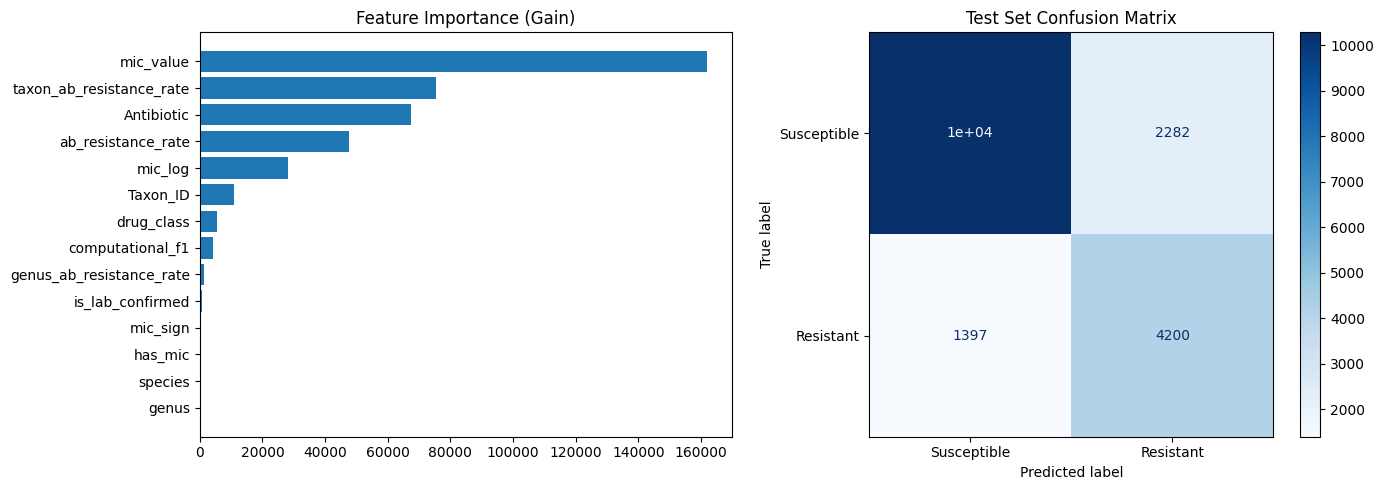

Saved model, lookup tables, and results plot.


In [9]:
# ============================================================
# CELL 5 — LightGBM Training
# ============================================================
# IMPROVEMENT: StratifiedKFold CV added to verify stability
# before committing to test-set evaluation.
# ============================================================

import lightgbm as lgb
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, roc_auc_score
)

X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X_train[FINAL_FEATURES], y_train, w_train,
    test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

print(f"Train   : {len(X_tr):,}")
print(f"Val     : {len(X_val):,}")
print(f"Test    : {len(X_test):,}")

lgb_train = lgb.Dataset(
    X_tr, label=y_tr, weight=w_tr,
    categorical_feature=LGBM_CAT_FEATURES, free_raw_data=False
)
lgb_val = lgb.Dataset(
    X_val, label=y_val, weight=w_val,
    categorical_feature=LGBM_CAT_FEATURES,
    reference=lgb_train, free_raw_data=False
)

params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'boosting_type'    : 'gbdt',
    'verbose'          : -1,
    'random_state'     : RANDOM_STATE,
    'n_jobs'           : -1,
    'num_leaves'       : 127,
    'max_depth'        : -1,
    'min_child_samples': 20,
    'learning_rate'    : 0.05,
    'n_estimators'     : 2000,
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'min_split_gain'   : 0.01,
    'is_unbalance'     : True,
    'cat_smooth'       : 10,
    'max_cat_threshold': 32,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

print("Training LightGBM...")
model = lgb.train(params, lgb_train, valid_sets=[lgb_val], callbacks=callbacks)

# ── IMPROVEMENT: 5-fold StratifiedKFold CV ─────────────────
print("\nRunning 5-fold StratifiedKFold CV on training set...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_aucs = []
for fold, (tr_i, val_i) in enumerate(skf.split(X_train[FINAL_FEATURES], y_train), 1):
    fold_lgb_tr = lgb.Dataset(
        X_train[FINAL_FEATURES].iloc[tr_i], label=y_train.iloc[tr_i],
        weight=w_train.iloc[tr_i], categorical_feature=LGBM_CAT_FEATURES
    )
    fold_lgb_val = lgb.Dataset(
        X_train[FINAL_FEATURES].iloc[val_i], label=y_train.iloc[val_i],
        categorical_feature=LGBM_CAT_FEATURES, reference=fold_lgb_tr
    )
    fold_model = lgb.train(
        {**params, 'n_estimators': model.best_iteration or 500},
        fold_lgb_tr, valid_sets=[fold_lgb_val],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    fold_proba = fold_model.predict(X_train[FINAL_FEATURES].iloc[val_i])
    fold_auc = roc_auc_score(y_train.iloc[val_i], fold_proba)
    cv_aucs.append(fold_auc)
    print(f"  Fold {fold} AUC: {fold_auc:.4f}")
print(f"  CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

# Threshold tuning on validation set
val_proba = model.predict(X_val)
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
FINAL_THRESHOLD = float(np.clip(thresholds[np.argmax(f1_scores)], 0.30, 0.55))

y_proba_test = model.predict(X_test[FINAL_FEATURES])
y_pred_test  = (y_proba_test >= FINAL_THRESHOLD).astype(int)

print(f"\nTest AUC-ROC: {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"Threshold   : {FINAL_THRESHOLD:.4f}")
print(classification_report(y_test, y_pred_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_df = pd.DataFrame({
    'feature'   : model.feature_name(),
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

axes[0].barh(importance_df['feature'], importance_df['importance'])
axes[0].set_title('Feature Importance (Gain)')

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Susceptible', 'Resistant']).plot(
    ax=axes[1], cmap='Blues'
)
axes[1].set_title('Test Set Confusion Matrix')
plt.tight_layout()
plt.savefig('results_lgbm.png')
plt.show()

model.save_model('amr_lgbm_model.txt')
joblib.dump(ab_rate_full, 'ab_rate_full.joblib')
joblib.dump(taxon_ab_rate_full, 'taxon_ab_rate_full.joblib')
joblib.dump(genus_ab_rate_full, 'genus_ab_rate_full.joblib')
print("Saved model, lookup tables, and results plot.")


In [10]:
# ============================================================
# CELL 6 — Pseudo-labeling with Balanced Harvesting
# ============================================================

import pandas as pd
import numpy as np

for col in LGBM_CAT_FEATURES:
    if col in df_unlabeled_enc.columns and col in X_train.columns:
        train_cat_dtype = X_train[col].dtype
        df_unlabeled_enc[col] = df_unlabeled_enc[col].astype(train_cat_dtype)

unlabeled_probs = model.predict(df_unlabeled_enc[FINAL_FEATURES])
df_unlabeled_enc['pred_prob'] = unlabeled_probs

print("STEP 6A — Unlabeled score distribution:")
print(f"  Min={unlabeled_probs.min():.4f} | Max={unlabeled_probs.max():.4f} | Mean={unlabeled_probs.mean():.4f}")

bins = [0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
counts, _ = np.histogram(unlabeled_probs, bins=bins)
print("\n  Probability histogram:")
for i in range(len(counts)):
    bar = '█' * int(counts[i] / max(counts) * 20)
    print(f"    {bins[i]:.1f}–{bins[i+1]:.1f} : {bar} {counts[i]:,}")

df_pseudo_res     = df_unlabeled_enc[df_unlabeled_enc['pred_prob'] >= PSEUDO_CONF_R].copy()
df_pseudo_sus_all = df_unlabeled_enc[df_unlabeled_enc['pred_prob'] <= PSEUDO_CONF_S].copy()
df_pseudo_res['target']     = 1
df_pseudo_sus_all['target'] = 0

n_res = len(df_pseudo_res); n_sus_raw = len(df_pseudo_sus_all)
print(f"\nSTEP 6B — Harvest (R>={PSEUDO_CONF_R} | S<={PSEUDO_CONF_S}):")
print(f"  Resistant   : {n_res:,}")

max_sus = int(n_res * MAX_SUS_RATIO)
df_pseudo_sus = df_pseudo_sus_all.sort_values('pred_prob').head(max_sus).copy() if n_sus_raw > max_sus else df_pseudo_sus_all.copy()
n_sus = len(df_pseudo_sus)
print(f"  Susceptible : {n_sus_raw:,} → {n_sus:,} (capped)" if n_sus_raw > max_sus else f"  Susceptible : {n_sus:,}")
print(f"  Final ratio : {n_sus/max(n_res,1):.2f}:1")

df_pseudo = pd.concat([df_pseudo_res, df_pseudo_sus], axis=0)
df_pseudo['sample_weight']    = 0.5
df_pseudo['is_lab_confirmed'] = 0

df_train_current = X_train[FINAL_FEATURES].copy()
df_train_current['target']        = y_train.values
df_train_current['sample_weight'] = w_train.values

cols_to_keep = FINAL_FEATURES + ['target', 'sample_weight']
df_train_extended = pd.concat(
    [df_train_current[cols_to_keep], df_pseudo[cols_to_keep]], axis=0
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_ext = df_train_extended[FINAL_FEATURES]
y_train_ext = df_train_extended['target']
w_train_ext = df_train_extended['sample_weight']

neg_ext = (y_train_ext == 0).sum()
pos_ext = (y_train_ext == 1).sum()

print(f"\n{'='*50}")
print(f"  PSEUDO-LABELING COMPLETE")
print(f"  Original : {len(df_train_current):,}")
print(f"  Pseudo   : {len(df_pseudo):,}")
print(f"  Extended : {len(df_train_extended):,}")
print(f"  Ratio    : {neg_ext/pos_ext:.2f}:1")
print("\n✅ Ready for Cell 7.")


STEP 6A — Unlabeled score distribution:
  Min=0.0004 | Max=0.9991 | Mean=0.4168

  Probability histogram:
    0.0–0.1 : ████████████████████ 14,131
    0.1–0.2 : █ 785
    0.2–0.3 :  185
    0.3–0.4 :  211
    0.4–0.6 : ████ 3,347
    0.6–0.7 :  40
    0.7–0.8 : █ 809
    0.8–0.9 : ██ 2,045
    0.9–1.0 : ███████████ 8,253

STEP 6B — Harvest (R>=0.8 | S<=0.2):
  Resistant   : 10,298
  Susceptible : 14,916
  Final ratio : 1.45:1

  PSEUDO-LABELING COMPLETE
  Original : 72,660
  Pseudo   : 25,214
  Extended : 97,874
  Ratio    : 1.99:1

✅ Ready for Cell 7.


STEP 7A — Final training on extended dataset
  Extended train : 88,086
  Validation     : 9,788

[100]	valid_0's auc: 0.918937
  Best iteration : 126
  Best AUC (val) : 0.9190

  FINAL MODEL — TEST SET RESULTS (LightGBM)
  AUC-ROC              : 0.8872
  Threshold            : 0.5500
                 precision    recall  f1-score   support

Susceptible (0)       0.87      0.85      0.86     12569
  Resistant (1)       0.68      0.71      0.69      5597

       accuracy                           0.81     18166
      macro avg       0.77      0.78      0.78     18166
   weighted avg       0.81      0.81      0.81     18166



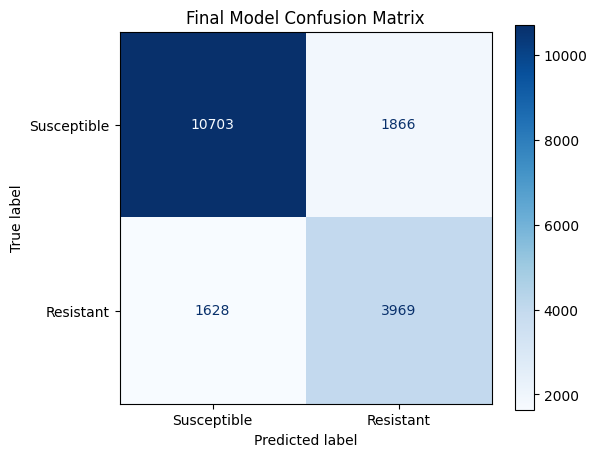


Saved: LoopVerse_Submission_LGBM.csv and amr_lgbm_final_model.txt


In [11]:
# ============================================================
# CELL 7 — Final Retraining on Extended Dataset
# ============================================================

import lightgbm as lgb
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)

X_tr_ext, X_val_ext, y_tr_ext, y_val_ext, w_tr_ext, w_val_ext = train_test_split(
    X_train_ext, y_train_ext, w_train_ext,
    test_size=0.10, stratify=y_train_ext, random_state=RANDOM_STATE
)

print(f"STEP 7A — Final training on extended dataset")
print(f"  Extended train : {len(X_tr_ext):,}")
print(f"  Validation     : {len(X_val_ext):,}\n")

lgb_train_ext = lgb.Dataset(
    X_tr_ext, label=y_tr_ext, weight=w_tr_ext,
    categorical_feature=LGBM_CAT_FEATURES, free_raw_data=False
)
lgb_val_ext = lgb.Dataset(
    X_val_ext, label=y_val_ext, weight=w_val_ext,
    categorical_feature=LGBM_CAT_FEATURES,
    reference=lgb_train_ext, free_raw_data=False
)

final_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'boosting_type'    : 'gbdt',
    'verbose'          : -1,
    'random_state'     : RANDOM_STATE,
    'n_jobs'           : -1,
    'num_leaves'       : 127,
    'max_depth'        : -1,
    'min_child_samples': 20,
    'learning_rate'    : 0.05,
    'n_estimators'     : 2000,
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'min_split_gain'   : 0.01,
    'is_unbalance'     : True,
    'cat_smooth'       : 10,
    'max_cat_threshold': 32,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

final_model = lgb.train(final_params, lgb_train_ext, valid_sets=[lgb_val_ext], callbacks=callbacks)

print(f"  Best iteration : {final_model.best_iteration}")
print(f"  Best AUC (val) : {final_model.best_score['valid_0']['auc']:.4f}\n")

# Threshold tuning on validation PR curve
val_probs_ext = final_model.predict(X_val_ext)
precisions, recalls, thresholds = precision_recall_curve(y_val_ext, val_probs_ext)
f1_scores_val  = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_thresh = float(np.clip(thresholds[np.argmax(f1_scores_val)], 0.30, 0.55))

test_probs  = final_model.predict(X_test[FINAL_FEATURES])
final_preds = (test_probs >= best_thresh).astype(int)
final_auc   = roc_auc_score(y_test, test_probs)

print(f"{'='*55}")
print(f"  FINAL MODEL — TEST SET RESULTS (LightGBM)")
print(f"{'='*55}")
print(f"  AUC-ROC              : {final_auc:.4f}")
print(f"  Threshold            : {best_thresh:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, final_preds,
      target_names=['Susceptible (0)', 'Resistant (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, final_preds),
    display_labels=['Susceptible', 'Resistant']
).plot(ax=ax, cmap='Blues')
ax.set_title('Final Model Confusion Matrix')
plt.show()

label_map = {0: 'Susceptible', 1: 'Resistant'}
df_unlabeled_aligned = df_unlabeled.reset_index(drop=True)
submission = pd.DataFrame({
    'Genome_ID'  : df_unlabeled_aligned.get('Genome ID', df_unlabeled_aligned.index),
    'Antibiotic' : df_unlabeled_aligned.get('Antibiotic', 'unknown'),
})

final_probs_unlabeled = final_model.predict(df_unlabeled_enc[FINAL_FEATURES])
submission['Predicted_Phenotype'] = [label_map[1 if p >= best_thresh else 0] for p in final_probs_unlabeled]

submission.to_csv('LoopVerse_Submission_LGBM.csv', index=False)
final_model.save_model('amr_lgbm_final_model.txt')
print("\nSaved: LoopVerse_Submission_LGBM.csv and amr_lgbm_final_model.txt")


Loading saved LightGBM model...

  FINAL HOLDOUT EVALUATION (LightGBM)
  AUC-ROC              : 0.8872
  F1 Resistant   (1)   : 0.6944

                 precision    recall  f1-score   support

Susceptible (0)       0.87      0.85      0.86     12569
  Resistant (1)       0.68      0.71      0.69      5597

       accuracy                           0.81     18166
      macro avg       0.77      0.78      0.78     18166
   weighted avg       0.81      0.81      0.81     18166

Saved: /content/drive/Shareddrives/ML_Loopverse_2.0/LightBGM Model/confusion_matrix_holdout.png


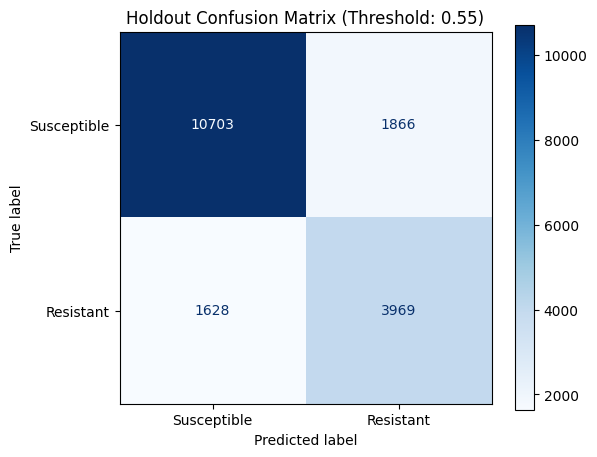

In [12]:
# ============================================================
# CELL 8 — Standalone Model Testing (Holdout Set)
# ============================================================

import lightgbm as lgb
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import os

print("Loading saved LightGBM model...")
loaded_model = lgb.Booster(model_file='amr_lgbm_final_model.txt')

test_probs = loaded_model.predict(X_test[FINAL_FEATURES])

try:
    threshold_to_use = best_thresh
except NameError:
    threshold_to_use = 0.50

test_preds  = (test_probs >= threshold_to_use).astype(int)
test_auc    = roc_auc_score(y_test, test_probs)
test_f1_res = f1_score(y_test, test_preds, pos_label=1)

print("\n=======================================================")
print("  FINAL HOLDOUT EVALUATION (LightGBM)")
print("=======================================================")
print(f"  AUC-ROC              : {test_auc:.4f}")
print(f"  F1 Resistant   (1)   : {test_f1_res:.4f}")
print("=======================================================\n")
print(classification_report(y_test, test_preds, target_names=['Susceptible (0)', 'Resistant (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Susceptible', 'Resistant']).plot(
    ax=ax, cmap='Blues', values_format='d'
)
ax.set_title(f'Holdout Confusion Matrix (Threshold: {threshold_to_use:.2f})')
plt.grid(False)

save_path = '/content/drive/Shareddrives/ML_Loopverse_2.0/LightBGM Model'
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path, 'confusion_matrix_holdout.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.join(save_path, 'confusion_matrix_holdout.png')}")
plt.show()


In [13]:
# ============================================================
# CELL 9 — Backup to Google Drive (LightGBM)
# ============================================================

import shutil, os
import pandas as pd
import joblib

drive_folder = '/content/drive/Shareddrives/ML_Loopverse_2.0/LightBGM Model'
os.makedirs(drive_folder, exist_ok=True)

files_to_save = [
    'LoopVerse_Submission_LGBM.csv',
    'amr_lgbm_final_model.txt',
    'amr_lgbm_model.txt',
    'results_lgbm.png',
    'eda_overview_lgbm.png',
    'ab_rate_full.joblib',
    'taxon_ab_rate_full.joblib',
    'genus_ab_rate_full.joblib'
]

print(f"Backing up LightGBM files to: {drive_folder}\n")
for file in files_to_save:
    if os.path.exists(file):
        shutil.copy2(file, os.path.join(drive_folder, file))
        print(f"✅ {file}")
    else:
        print(f"❌ Not found: {file}")

print("\nSaving DataFrames to Drive...")
try:
    clean_path = os.path.join(drive_folder, 'cleaned_labeled_data_lgbm.csv')
    df_clean.to_csv(clean_path, index=False)
    print(f"✅ cleaned_labeled_data_lgbm.csv ({len(df_clean):,} rows)")
except NameError:
    print("❌ Could not save df_clean")

try:
    mic_map_path = os.path.join(drive_folder, 'mic_sign_map.joblib')
    MIC_SIGN_MAP_SAVE = {'<=': -1.0, '<': -0.5, '=': 0.0, '==': 0.0, 'exact': 0.0,
                         '>=': 1.0, '>': 0.5, 'unknown': 0.0}
    joblib.dump(MIC_SIGN_MAP_SAVE, mic_map_path)
    print("✅ mic_sign_map.joblib")
except Exception as e:
    print(f"❌ Could not save MIC map: {e}")

print("\n✅ LightGBM pipeline backup complete!")


Backing up LightGBM files to: /content/drive/Shareddrives/ML_Loopverse_2.0/LightBGM Model

✅ LoopVerse_Submission_LGBM.csv
✅ amr_lgbm_final_model.txt
✅ amr_lgbm_model.txt
✅ results_lgbm.png
✅ eda_overview_lgbm.png
✅ ab_rate_full.joblib
✅ taxon_ab_rate_full.joblib
✅ genus_ab_rate_full.joblib

Saving DataFrames to Drive...
✅ cleaned_labeled_data_lgbm.csv (90,826 rows)
✅ mic_sign_map.joblib

✅ LightGBM pipeline backup complete!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
